In [60]:

import netCDF4 as nc4
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
from scipy import stats



import glob as glob
import os
from collections import OrderedDict
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
import matplotlib.pyplot as plt
import matplotlib as mpl
from pylab import *; 
import cartopy
import cartopy.crs as ccrs
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

def monthly_anomaly(data,data_control,type='standard',NANDATA = False):
    monthly_data = separate_by_month_arrays(data)
    monthly_data_control = np.nanmean(separate_by_month_arrays(data_control),axis=1)
    new_data=[]
    if type == 'percent':
        return percent_anomaly(data,data_control)
    if type == 'standard':
        for yr in range(int(len(data)/12.0)):
            for mo in range(12):
                new_data.append(monthly_data[mo][yr] - monthly_data_control[mo])
        return new_data
    if type == 'sd':
        mdc_std = np.nanstd(separate_by_month_arrays(data_control),axis=1)
        for yr in range(int(len(data)/12.0)):
    	    for mo in range(12):
	          new_data.append( (monthly_data[mo][yr] - monthly_data_control[mo]) *(mdc_std[mo]**-1))
        return new_data

    
    
    
    


from datetime import datetime, timedelta

def convert_days_to_date(days_since_origin, origin_date_str="0001-01-01"):
    """
    Converts a number of days since a specified origin date to an actual date.

    Args:
        days_since_origin (int or float): The number of days since the origin.
        origin_date_str (str): The origin date in 'YYYY-MM-DD' format.

    Returns:
        datetime.datetime: The calculated actual date and time.
    """
    # 1. Define the origin date as a datetime object
    origin_date = datetime.strptime(origin_date_str, "%Y-%m-%d")

    # 2. Create a timedelta object from the number of days
    delta = timedelta(days=days_since_origin)

    # 3. Add the timedelta to the origin date to get the resulting date
    actual_date = origin_date + delta

    return actual_date



def running_mean(data,n):
  data_n = [np.nan]*n; t = n
  while t in range(len(data)-n):
    data_n.append(np.nanmean(data[t-n:t+n+1]))
    t = t+1
  return data_n + [np.nan]*n






def running_mean(data,n):
  data_n = [np.nan]*n; t = n
  while t in range(len(data)-n):
    data_n.append(np.nanmean(data[t-n:t+n+1]))
    t = t+1
  return data_n + [np.nan]*n



def separate_by_month_arrays(dataset):
	k=0
	jan=[];feb=[];march=[];apr=[];may=[];jun=[];july=[];aug=[];sep=[];oc=[];nov=[];dec=[];
	while k <= (len(dataset)-12):
		jan.append((dataset[k]))
		feb.append((dataset[k+1]))
		march.append((dataset[k+2]))
		apr.append((dataset[k+3]))
		may.append((dataset[k+4]))
		jun.append((dataset[k+5]))
		july.append((dataset[k+6]))
		aug.append((dataset[k+7]))
		sep.append((dataset[k+8]))
		oc.append((dataset[k+9]))
		nov.append((dataset[k+10]))
		dec.append((dataset[k+11]))
		k = k+12;
	return [jan,feb,march,apr,may,jun,july,aug,sep,oc,nov,dec]

In [45]:
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'
these_cases=['nw_cntrl_tuv_01','nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01']
these_variables=['FSDS','TS']

files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.cam.h0.'+VAR+'.*.nc'))

   
files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))

   

In [49]:
for case in these_cases:
    print(files[case])

{'FSDS': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_cntrl_tuv_01/nw_cntrl_tuv_01.pop.h.FSDS.000102-002001.nc'], 'TS': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_cntrl_tuv_01/nw_cntrl_tuv_01.pop.h.TS.000102-002001.nc']}
{'FSDS': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_ur_150_tuv_01/nw_ur_150_tuv_01.pop.h.FSDS.000502-002101.nc'], 'TS': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_ur_150_tuv_01/nw_ur_150_tuv_01.pop.h.TS.000502-002101.nc']}
{'FSDS': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_ip_46p8_tuv_ens01/nw_ip_46p8_tuv_ens01.pop.h.FSDS.000502-002101.nc'], 'TS': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_ip_46p8_tuv_ens01/nw_ip_46p8_tuv_ens01.pop.h.TS.000502-002101.nc']}
{'FSDS': ['/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_ip_5tg_tuv_ens01/nw_ip_5tg_tuv_ens01.pop.h.FSDS.000502-002101.nc'], 'TS': ['/scratch/alpine/

In [55]:
monthly_data={}
for case in these_cases:
    print(case)
    monthly_data[case]={}
    for VAR in these_variables:
        ds = xr.open_mfdataset(files[case][VAR])
        weights = np.cos(np.deg2rad(ds.lat))
        ds_weighted = ds.weighted(weights)
        weighted_mean = ds_weighted.mean(("lon","lat"))
        monthly_data[case][VAR]=weighted_mean[VAR].values
    
    

nw_cntrl_tuv_01
dict_keys(['nw_ip_5tg_tuv_ens01'])
nw_ur_150_tuv_01
dict_keys(['nw_ip_5tg_tuv_ens01'])
nw_ip_46p8_tuv_ens01
dict_keys(['nw_ip_5tg_tuv_ens01'])
nw_ip_5tg_tuv_ens01
dict_keys(['nw_ip_5tg_tuv_ens01'])


nw_cntrl_tuv_01
nw_ur_150_tuv_01
nw_ip_46p8_tuv_ens01
nw_ip_5tg_tuv_ens01
nw_cntrl_tuv_01
nw_ur_150_tuv_01
nw_ip_46p8_tuv_ens01
nw_ip_5tg_tuv_ens01


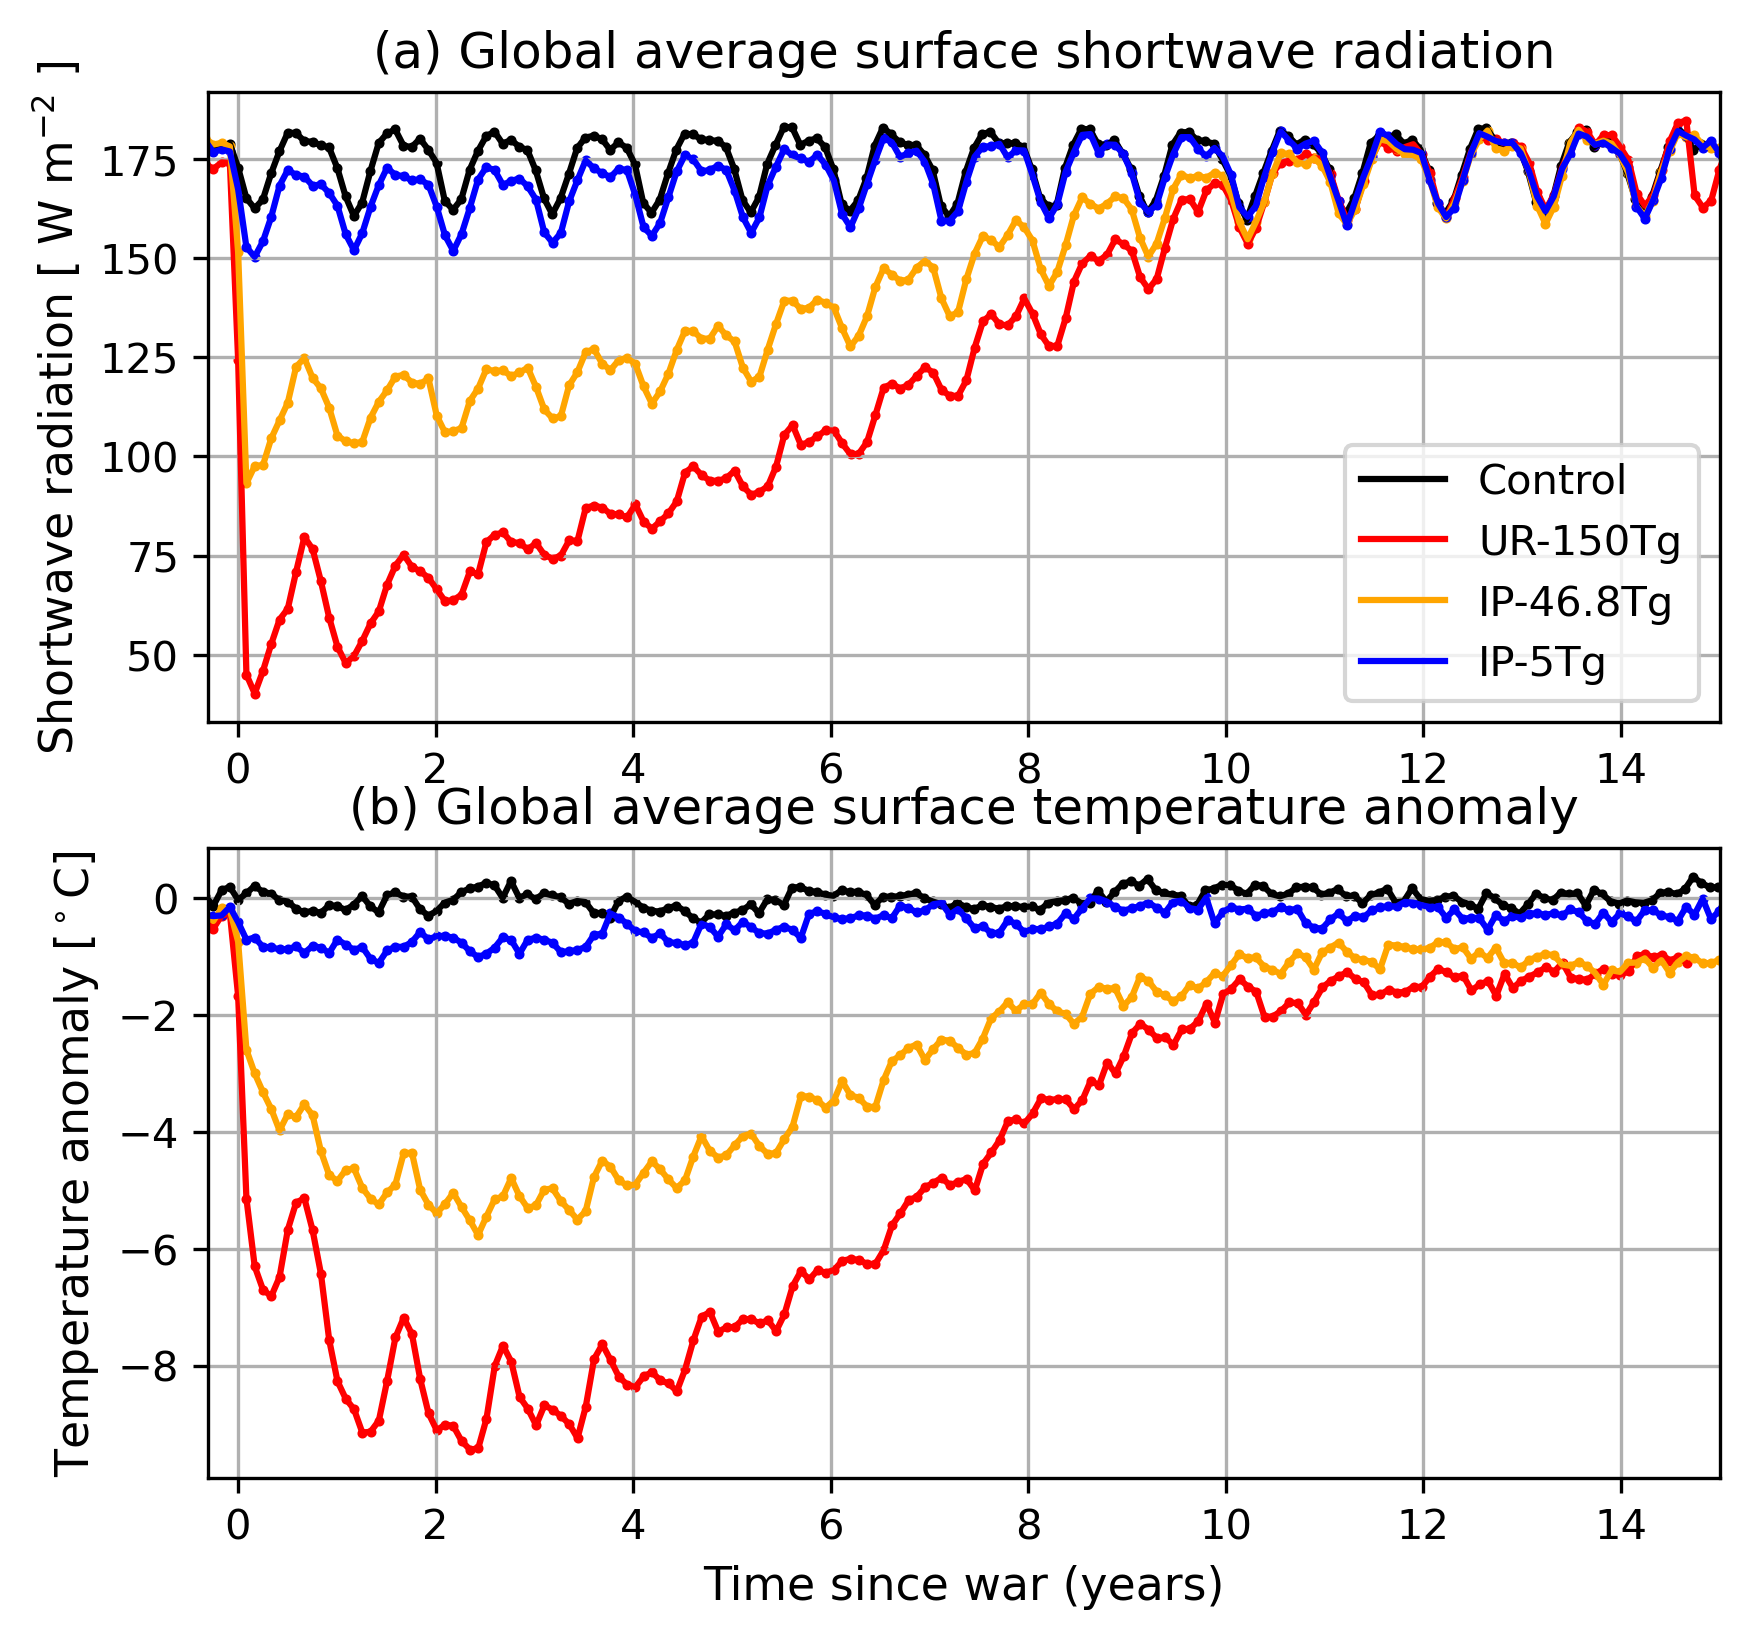

In [61]:

monthly_data_plot={}
for case in these_cases:
    #print(case)
    monthly_data_plot[case]={}
    for var in these_variables:
        monthly_data_plot[case][var] = monthly_data[case][var]

        
fig = plt.figure(figsize=(6.5,6),facecolor='white')
gs = fig.add_gridspec(2,1)
#plt.suptitle('Impact winter climate state',fontsize=18)

ax1=fig.add_subplot(gs[0,0],facecolor='white')#,projection=ccrs.Robinson(central_longitude=-60))


VAR='FSDS'

these_cases=['nw_cntrl_tuv_01','nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01']
offset={}
offset['nw_ip_46p8_tuv_ens01'] = -4 * (1/12.0)
offset['nw_ur_150_tuv_01']= -4 * (1/12.0) 
offset['nw_cntrl_tuv_01']= -4 *(1/12.0)
offset['nw_ip_5tg_tuv_ens01'] = -4 * (1/12.0)
case_colors={}
case_colors['nw_ur_150_tuv_01']='r'
case_colors['nw_cntrl_tuv_01']='k'
case_colors['nw_ip_46p8_tuv_ens01']='orange'
case_colors['nw_ip_5tg_tuv_ens01'] = 'blue'
case_labels={}
case_labels['nw_ur_150_tuv_01']='UR-150Tg'
case_labels['nw_cntrl_tuv_01']='Control'
case_labels['nw_ip_46p8_tuv_ens01'] = 'IP-46.8Tg'
case_labels['nw_ip_5tg_tuv_ens01'] = 'IP-5Tg'

# option to cycle control to make plots more digestable
CYCLE_CONTROL=False; TOTAL_CYCLES=4; case='nw_cntrl_tuv_01'
if CYCLE_CONTROL:
    one_cycle = list(monthly_data_plot[case][VAR])
    for cycle in range(TOTAL_CYCLES):
        monthly_data_plot[case][VAR] = list(monthly_data_plot[case][VAR]) + one_cycle
    

ax1.set_title('(a) Global average surface shortwave radiation',fontsize=12);
ax1.set_ylabel('Shortwave radiation [ W m$^{-2}$ ]',fontsize=11); #plt.axvline(8,color='grey',linestyle='--',linewidth=0.5); plt.axhline(0,color='k',linewidth=0.5)
#ax1.set_xlabel('Time since war (years)')
#ax1.set_xticks(np.array([12,24,36,48,60,72,84,96,108,120,132,144,156,168,180,192,204]),('1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17'),fontsize=10)

for case in these_cases:
    print(case)
    DATA = monthly_data_plot[case][VAR]
    ts = np.linspace(0,len(DATA),len(DATA)) * (1.0/12) + offset[case]
    ax1.plot(ts,np.array(DATA),label=case_labels[case],color=case_colors[case])#,linewidth=linewidths[case])
    ax1.scatter(ts,DATA,s=2,c=case_colors[case])

#ax1.axvline(ts[ 7*12 + 4],color='orange',linestyle='--',label='Date of emission',linewidth=0.7)
#ax1.set_ylim([145,180])
ax1.set_xlim([-0.3,15])
ax1.grid(); 
ax1.legend(loc='best')




VAR='TS'
ax2=fig.add_subplot(gs[1,0],facecolor='white')#,projection=ccrs.Robinson(central_longitude=-60))
ax2.set_title('(b) Global average surface temperature anomaly',fontsize=12);
ax2.set_ylabel('Temperature anomaly [$^\circ$C]',fontsize=11)
ax2.set_xlabel('Time since war (years)',fontsize=11)
for case in these_cases:
    print(case)
    DATA = np.array(monthly_data_plot[case][VAR] )
    DATA = monthly_anomaly(DATA,monthly_data_plot['nw_cntrl_tuv_01'][VAR])
    ts = np.linspace(0,len(DATA),len(DATA)) * (1.0/12) + offset[case]
    ax2.plot(ts,np.array(DATA),label=case_labels[case],color=case_colors[case])#,linewidth=linewidths[case])
    ax2.scatter(ts,DATA,s=2,c=case_colors[case])

#ax1.axvline(ts[ 7*12 + 4],color='orange',linestyle='--',label='Date of emission',linewidth=0.7)
#ax1.set_ylim([145,180])
ax2.set_xlim([-0.3,15])
ax2.grid(); 
#ax2.legend(loc='best')

plt.show()

In [ ]:
# repeat the above process for Figure S2

# Figure S2


In [62]:
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'
these_cases=['nw_cntrl_tuv_01','nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01']
these_variables=['TUV_UVA','TUV_UVB']

files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.cam.h0.'+VAR+'.*.nc'))


        
   

In [64]:

monthly_data={}
for case in these_cases:
    print(case)
    monthly_data[case]={}
    for VAR in these_variables:
        ds = xr.open_mfdataset(files[case][VAR])
        weights = np.cos(np.deg2rad(ds.lat))
        ds_weighted = ds.weighted(weights)
        weighted_mean = ds_weighted.mean(("lon","lat"))
        monthly_data[case][VAR]=weighted_mean[VAR].values
    
    

nw_cntrl_tuv_01
nw_ur_150_tuv_01
nw_ip_46p8_tuv_ens01
nw_ip_5tg_tuv_ens01


nw_cntrl_tuv_01
nw_ur_150_tuv_01
nw_ip_46p8_tuv_ens01
nw_ip_5tg_tuv_ens01
nw_cntrl_tuv_01
nw_ur_150_tuv_01
nw_ip_46p8_tuv_ens01
nw_ip_5tg_tuv_ens01


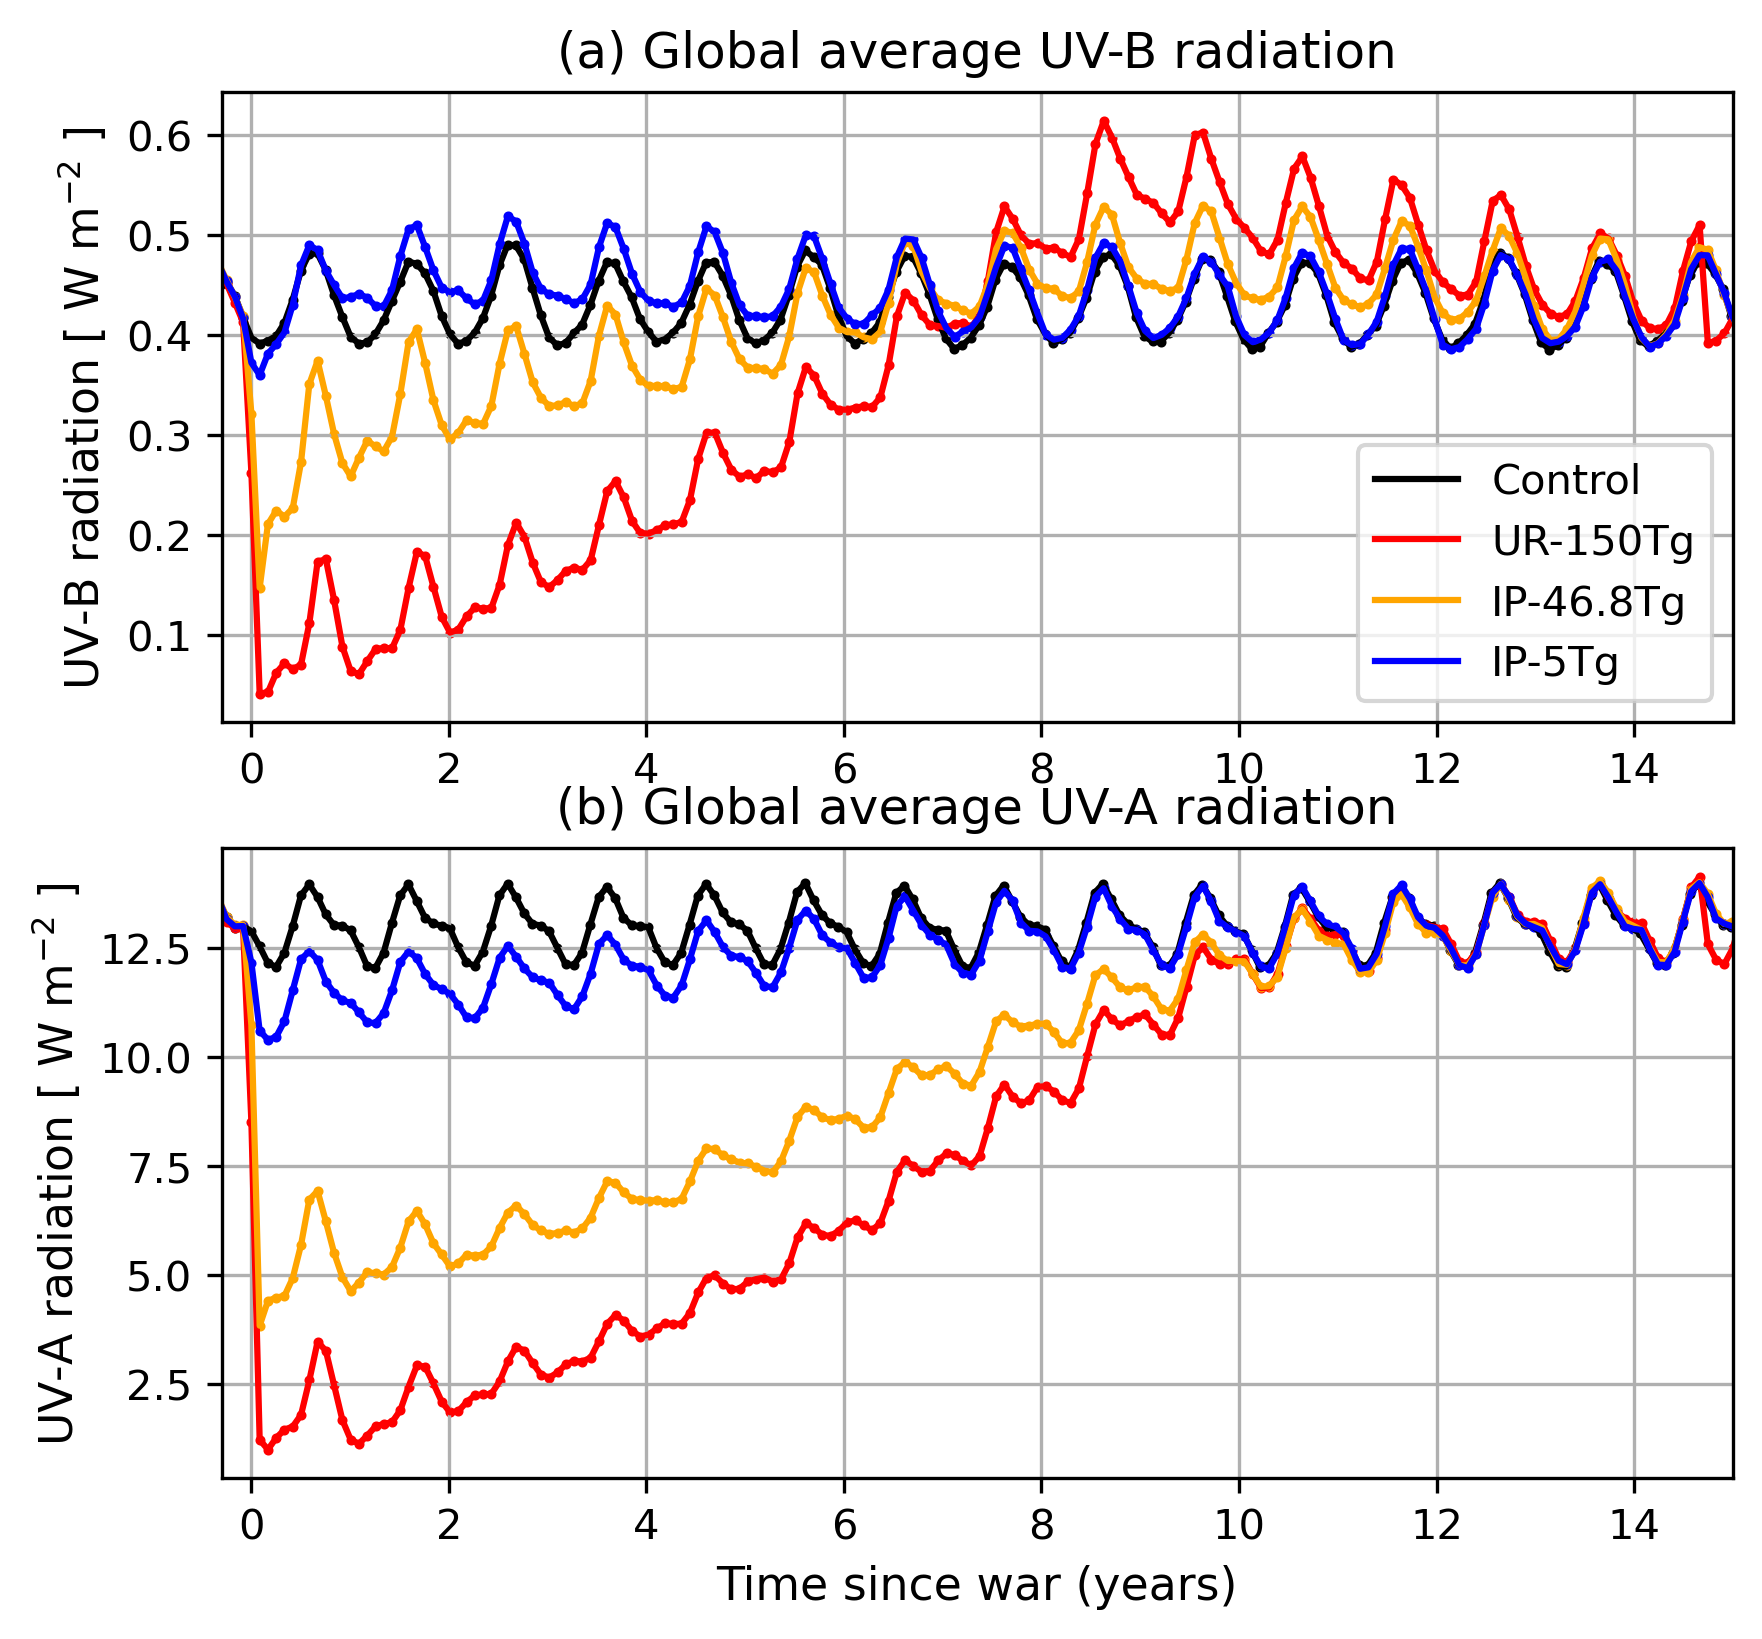

In [65]:

monthly_data_plot={}
for case in these_cases:
    #print(case)
    monthly_data_plot[case]={}
    for var in these_variables:
        monthly_data_plot[case][var] = monthly_data[case][var]


fig = plt.figure(figsize=(6.5,6),facecolor='white')
gs = fig.add_gridspec(2,1)
#plt.suptitle('Impact winter climate state',fontsize=18)

ax1=fig.add_subplot(gs[0,0],facecolor='white')#,projection=ccrs.Robinson(central_longitude=-60))


VAR='TUV_UVB'

these_cases=['nw_cntrl_tuv_01','nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01']
offset={}
offset['nw_ip_46p8_tuv_ens01'] = -4 * (1/12.0)
offset['nw_ur_150_tuv_01']= -4 * (1/12.0) 
offset['nw_cntrl_tuv_01']= -4 *(1/12.0)
offset['nw_ip_5tg_tuv_ens01'] = -4 * (1/12.0)
case_colors={}
case_colors['nw_ur_150_tuv_01']='r'
case_colors['nw_cntrl_tuv_01']='k'
case_colors['nw_ip_46p8_tuv_ens01']='orange'
case_colors['nw_ip_5tg_tuv_ens01'] = 'blue'
case_labels={}
case_labels['nw_ur_150_tuv_01']='UR-150Tg'
case_labels['nw_cntrl_tuv_01']='Control'
case_labels['nw_ip_46p8_tuv_ens01'] = 'IP-46.8Tg'
case_labels['nw_ip_5tg_tuv_ens01'] = 'IP-5Tg'

# option to cycle control to make plots more digestable
CYCLE_CONTROL=False; TOTAL_CYCLES=4; case='nw_cntrl_tuv_01'
if CYCLE_CONTROL:
    one_cycle = list(monthly_data_plot[case][VAR])
    for cycle in range(TOTAL_CYCLES):
        monthly_data_plot[case][VAR] = list(monthly_data_plot[case][VAR]) + one_cycle
    

ax1.set_title('(a) Global average UV-B radiation',fontsize=12);
ax1.set_ylabel('UV-B radiation [ W m$^{-2}$ ]',fontsize=11); #plt.axvline(8,color='grey',linestyle='--',linewidth=0.5); plt.axhline(0,color='k',linewidth=0.5)
#ax1.set_xlabel('Time since war (years)')
#ax1.set_xticks(np.array([12,24,36,48,60,72,84,96,108,120,132,144,156,168,180,192,204]),('1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17'),fontsize=10)

for case in these_cases:
    print(case)
    DATA = monthly_data_plot[case][VAR]
    ts = np.linspace(0,len(DATA),len(DATA)) * (1.0/12) + offset[case]
    ax1.plot(ts,np.array(DATA),label=case_labels[case],color=case_colors[case])#,linewidth=linewidths[case])
    ax1.scatter(ts,DATA,s=2,c=case_colors[case])

#ax1.axvline(ts[ 7*12 + 4],color='orange',linestyle='--',label='Date of emission',linewidth=0.7)
#ax1.set_ylim([145,180])
ax1.set_xlim([-0.3,15])
ax1.grid(); 
ax1.legend(loc='best')


VAR='TUV_UVA'
ax2=fig.add_subplot(gs[1,0],facecolor='white')#,projection=ccrs.Robinson(central_longitude=-60))
ax2.set_title('(b) Global average UV-A radiation',fontsize=12);
ax2.set_ylabel('UV-A radiation [ W m$^{-2}$ ]',fontsize=11)
ax2.set_xlabel('Time since war (years)',fontsize=11)
for case in these_cases:
    print(case)
    DATA = np.array(monthly_data_plot[case][VAR] )
    #DATA = monthly_anomaly(DATA,monthly_data['nw_cntrl_tuv_01'][VAR])
    ts = np.linspace(0,len(DATA),len(DATA)) * (1.0/12) + offset[case]
    ax2.plot(ts,np.array(DATA),label=case_labels[case],color=case_colors[case])#,linewidth=linewidths[case])
    ax2.scatter(ts,DATA,s=2,c=case_colors[case])

#ax1.axvline(ts[ 7*12 + 4],color='orange',linestyle='--',label='Date of emission',linewidth=0.7)
#ax1.set_ylim([145,180])
ax2.set_xlim([-0.3,15])
ax2.grid(); 
#ax2.legend(loc='best')

plt.show()

In [67]:
ds = xr.open_mfdataset('/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/nw_ur_150_tuv_01/nw_ur_150_tuv_01.cam.h0.FSDS.000502-002101.nc')
ds

<xarray.Dataset> Size: 10MB
Dimensions:  (time: 187, lat: 96, lon: 144)
Coordinates:
  * time     (time) object 1kB 0005-02-01 00:00:00 ... 0021-01-01 00:00:00
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Data variables:
    FSDS     (time, lat, lon) float32 10MB dask.array<chunksize=(187, 96, 144), meta=np.ndarray>

In [68]:
ds.time.values

array([cftime.DatetimeNoLeap(5, 2, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(5, 3, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(5, 4, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(5, 5, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(5, 6, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(5, 7, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(5, 8, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(5, 9, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(5, 10, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(5, 11, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(5, 12, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(6, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(6, 2, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(6, 3, 1, 0, 0, 0, 0, has_year_zero=True),
   